# Reproduction 1: Copy Number Variation (CNV) Heatmap

## Objective

The purpose of this analysis is to simulate and visualize Copy Number Variation (CNV) patterns across different cellular clones.

In the SpatialInferCNV paper, CNV profiles are used to identify genetically distinct clones within tissue samples. Regions with copy number gains and losses help researchers understand tumor heterogeneity and clonal evolution.

## Method

A synthetic CNV dataset was generated for seven clones (A-G) across chromosomes 1-22 and chromosome X.

The following CNV states were used:

- -1 = Copy Number Loss
- 0 = Normal Copy Number (Diploid)
- +1 = Copy Number Gain

The simulated data was then visualized using a heatmap.

## Expected Outcome

The heatmap should display different CNV patterns across clones, similar to the CNV visualizations presented in Figure 3 of the paper.

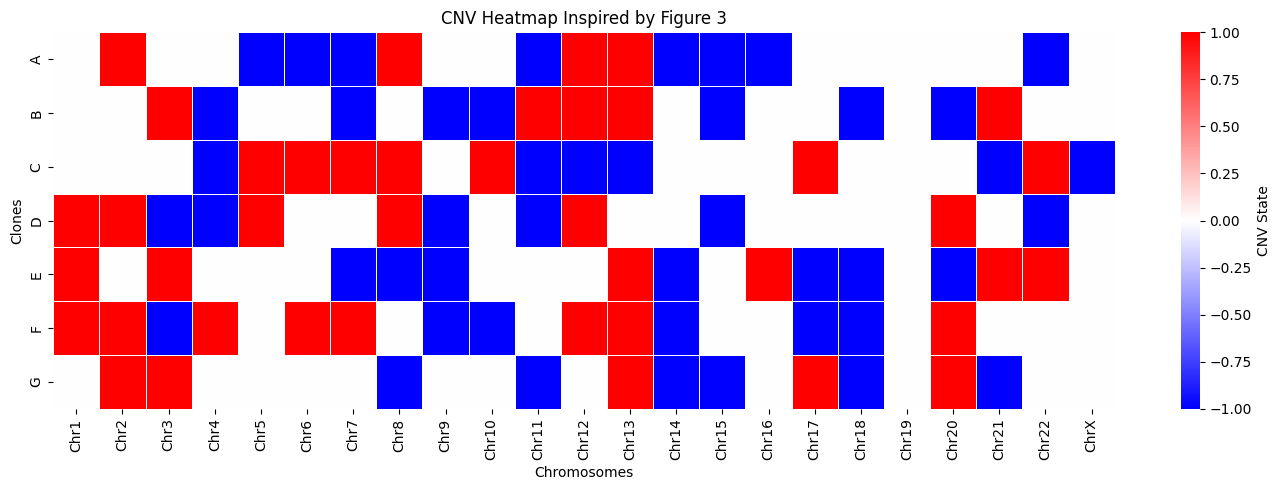

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Create fake CNV data
# -----------------------------

np.random.seed(42)

clones = ["A","B","C","D","E","F","G"]

chromosomes = [
    "Chr1","Chr2","Chr3","Chr4","Chr5",
    "Chr6","Chr7","Chr8","Chr9","Chr10",
    "Chr11","Chr12","Chr13","Chr14","Chr15",
    "Chr16","Chr17","Chr18","Chr19","Chr20",
    "Chr21","Chr22","ChrX"
]

# CNV states:
# -1 = loss
# 0 = diploid
# 1 = gain

cnv_matrix = np.random.choice(
    [-1,0,1],
    size=(len(clones), len(chromosomes)),
    p=[0.25,0.50,0.25]
)

df = pd.DataFrame(
    cnv_matrix,
    index=clones,
    columns=chromosomes
)

# -----------------------------
# Plot heatmap
# -----------------------------

plt.figure(figsize=(14,5))

sns.heatmap(
    df,
    cmap="bwr",
    center=0,
    linewidths=0.5,
    cbar_kws={"label":"CNV State"}
)

plt.title("CNV Heatmap Inspired by Figure 3")
plt.xlabel("Chromosomes")
plt.ylabel("Clones")

plt.tight_layout()

plt.show()

## Results and Interpretation

The generated heatmap displays copy number alterations across chromosomes for each simulated clone.

### Color Interpretation

- Blue regions represent copy number losses.
- White regions represent normal copy number.
- Red regions represent copy number gains.

### Biological Significance

In the original study, similar CNV patterns were used to identify genetically related groups of cells known as clones. Clones sharing similar CNV profiles may have originated from a common ancestral cell and accumulated mutations over time.

This simplified simulation demonstrates how CNV information can be visualized and compared across multiple clonal populations.

## Exporting the Heatmap

To preserve the generated figure for further analysis and inclusion in the GitHub repository, the heatmap is saved as a high-resolution PNG image.

This allows the visualization to be reused in reports, presentations, and project documentation.

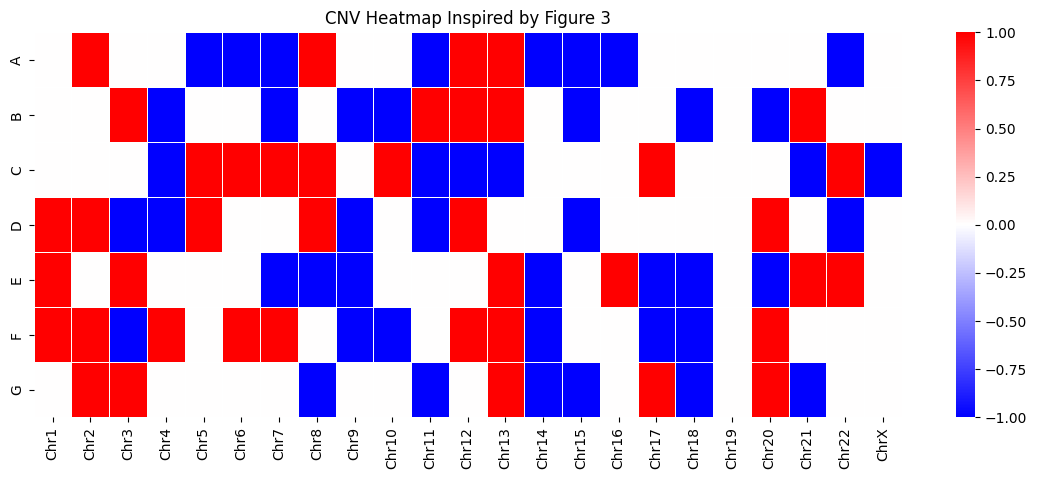

In [2]:
plt.figure(figsize=(14,5))

sns.heatmap(
    df,
    cmap="bwr",
    center=0,
    linewidths=0.5
)

plt.title("CNV Heatmap Inspired by Figure 3")

plt.savefig(
    "cnv_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Output Generated

- cnv_heatmap.png

This image represents the first reproduction result inspired by the SpatialInferCNV workflow and serves as a simplified representation of clone-specific CNV patterns.

# Reproduction 2: Clone Identification Using Hierarchical Clustering

## Objective

The goal of this analysis is to demonstrate how groups of spots with similar CNV profiles can be identified using hierarchical clustering.

In the SpatialInferCNV workflow, spots with similar inferred CNV patterns are grouped together to identify clonal populations within tissue samples.

## Method

A synthetic CNV matrix was generated for 50 spatial spots.

Hierarchical clustering was then applied using Ward's linkage method, which groups spots based on similarity in their CNV profiles.

The resulting dendrogram provides a visual representation of relationships among spots and potential clone structures.

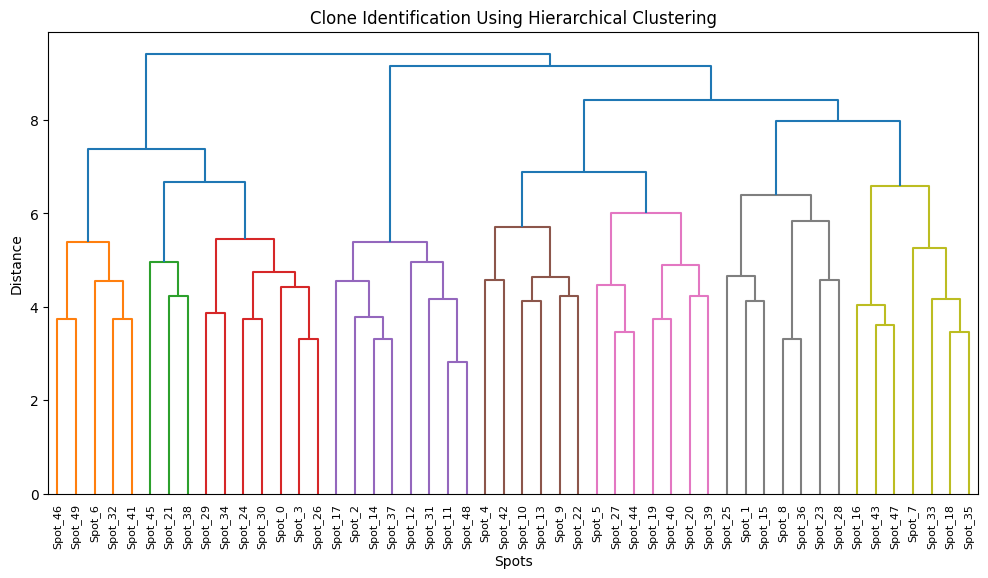

In [3]:
import numpy as np
import pandas as pd

from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import fcluster

import matplotlib.pyplot as plt

# -------------------------
# Fake CNV data
# -------------------------

np.random.seed(42)

clones = [f"Spot_{i}" for i in range(50)]

cnv_data = np.random.randint(
    -1,
    2,
    size=(50,20)
)

df = pd.DataFrame(cnv_data,index=clones)

# -------------------------
# Hierarchical clustering
# -------------------------

Z = linkage(df, method='ward')

plt.figure(figsize=(12,6))

dendrogram(
    Z,
    labels=df.index,
    leaf_rotation=90
)

plt.title("Clone Identification Using Hierarchical Clustering")
plt.xlabel("Spots")
plt.ylabel("Distance")

plt.show()

## Results and Interpretation

The dendrogram illustrates how spots cluster according to similarity in their CNV patterns.

### Key Observations

- Spots located on nearby branches are more genetically similar.
- Larger branches may represent distinct clones.
- Branching patterns can provide insight into clonal relationships and evolutionary history.

### Relation to the Paper

A similar clustering strategy is used in SpatialInferCNV to identify clones from inferred CNV profiles. These clone assignments are then used for downstream spatial analyses.

This reproduction demonstrates the basic concept of clone identification through hierarchical clustering.

# Reproduction 3: Spatial Clone Distribution

## Objective

One of the main contributions of the paper is the ability to visualize clones in their physical tissue locations.

The objective of this analysis is to create a simplified spatial representation of clone organization within a tissue section.

## Method

A synthetic tissue grid was generated and divided into four clone regions.

Small amounts of random mixing were introduced to simulate biological variability and overlap between neighboring clones.

Each clone was assigned a unique numerical identity and visualized spatially.

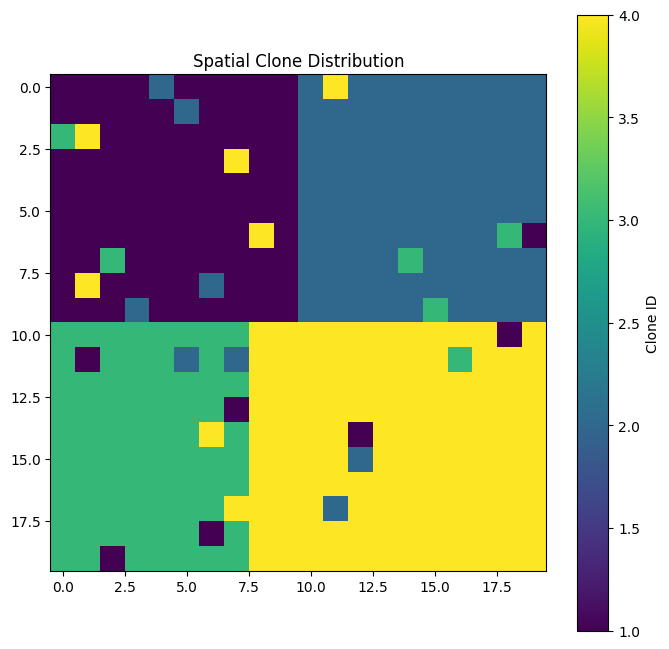

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Create tissue grid
# -------------------------

grid = np.zeros((20,20))

# Clone A
grid[:10,:10] = 1

# Clone B
grid[:10,10:] = 2

# Clone C
grid[10:,:8] = 3

# Clone D
grid[10:,8:] = 4

# Random mixing
np.random.seed(42)

for _ in range(40):
    x = np.random.randint(0,20)
    y = np.random.randint(0,20)
    grid[x,y] = np.random.choice([1,2,3,4])

# -------------------------
# Plot
# -------------------------

plt.figure(figsize=(8,8))

plt.imshow(grid)

plt.title("Spatial Clone Distribution")

plt.colorbar(label="Clone ID")

plt.savefig(
    "Spatial_Clone_Map.png",
    dpi=300
)

plt.show()

## Results and Interpretation

The spatial map displays the distribution of multiple clones across a simulated tissue section.

### Biological Interpretation

- Different colors represent different clone identities.
- Neighboring regions may belong to different clones.
- Mixed regions may indicate interactions or transitions between clonal populations.

### Relation to the Paper

The original study used spatial transcriptomics data to map clones directly onto tissue sections. These spatial maps revealed how genetically distinct populations occupy different physical regions of tissue.

This simplified visualization reproduces the core concept of spatial clonal organization.

# Reproduction 4: Clone Size Distribution

## Objective

The goal of this analysis is to compare the relative abundance of different clones.

Clone size is an important measure because larger clones may indicate successful expansion during tumor evolution, while smaller clones may represent emerging or less dominant populations.

## Method

A simulated dataset was created containing the number of spots associated with each clone.

The clone sizes were then visualized using a bar chart.

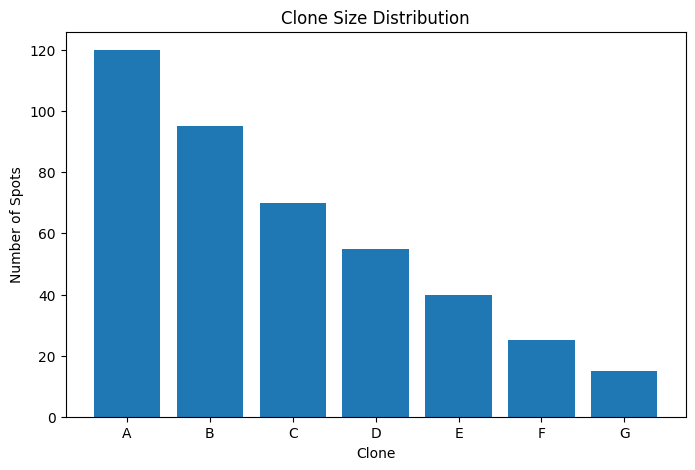

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

clone_sizes = pd.DataFrame({

    "Clone":["A","B","C","D","E","F","G"],

    "Spots":[120,95,70,55,40,25,15]

})

plt.figure(figsize=(8,5))

plt.bar(
    clone_sizes["Clone"],
    clone_sizes["Spots"]
)

plt.title("Clone Size Distribution")

plt.xlabel("Clone")

plt.ylabel("Number of Spots")

plt.savefig(
    "Clone_Size_Distribution.png",
    dpi=300
)

plt.show()

## Results and Interpretation

The bar chart summarizes the relative sizes of different clones.

### Key Observations

- Clone A is the largest clone in the simulated dataset.
- Several smaller clones are also present.
- The distribution illustrates clonal heterogeneity within a tissue sample.

### Relation to the Paper

The SpatialInferCNV study identified multiple clone populations within tissues and examined how these clones differed in abundance and spatial distribution.

This simplified analysis demonstrates how clone composition can be visualized and compared.

## Conclusion

Through these reproductions, several core concepts from the SpatialInferCNV paper were explored:

1. Visualization of copy number variation patterns.
2. Identification of clone groups through clustering.
3. Spatial mapping of clones across tissue.
4. Comparison of clone abundance and heterogeneity.

Although simplified, these analyses provide an intuitive understanding of the biological and computational principles underlying the SpatialInferCNV workflow.